In [162]:
import numpy as np
import matplotlib.pyplot as plt

Logistic regression is a type of regression model that predicts a probability.
It is a propular technique for buidling models that discriminate between two possible outcomes including classification tasks.

$$ f(x) = sigmoid(w * x + b) $$

In [163]:
x_email = np.array([
[10, 5, 8],
[7, 6, 12],
[4, 2, 18],
[13, 20, 35]
]) #these are the features of the email for example the number of links in the email.

y_email = np.array([1, 0, 1, 0]) #this is the out put we predict

Sigmoid function is the translator that takes any number and converts it to a probability between 0 and 1.
A sigmoid curve is one under a family of S-Shaped curves the logistic functions from which logistic regression gets its name.
We can use it to map the outputs of our linear mode to a continuous probability range.

$$sigmoid(z) = 1 / (1 + e^-z)$$

In [164]:
def sigmoid(z):
    return 1/ (1 + np.exp(-z)) #this the formula we use in logistic regressiom for values of 1 and 0.


In [165]:
def predict(X, w, b): #
    m = X.shape[0] #this enables us to get the number of elements in the dataset
    predictions = np.zeros(m) #this is the array we will use to store the predictions we make for each email

    for i in range(m):
        z = np.dot(X[i], w) + b #helps us multiply all the features with the weights and add the bias to it
        predictions[i] = sigmoid(z) #this gives us the predicted value for each email
    return predictions

Cost 

In [166]:
def compute_cost(X, y, w, b):
    m = X.shape[0]
    cost = 0.0

    for i in range(m):
        z_i = np.dot(X[i], w) + b
        f_i = sigmoid(z_i)
        cost += y[i] * np.log(f_i) + (1 - y[i]) * np.log(1 - f_i) #converts z to a value between 0 and 1 and then calculates the cost for each email

    cost = -cost / m
    return cost

In [167]:
def compute_gradient(X, y, w, b):
    m = X.shape[0]
    n = X.shape[1]

    dj_dw = np.zeros(n)
    dj_db = 0.0
    for i in range(m):
        z_i = np.dot(X[i], w) + b
        f_i = sigmoid(z_i)
        err_i = f_i - y[i] #this gives us the error for each email

        for j in range(n):
            dj_dw[j] += err_i * X[i][j] #this gives us the gradient for each weight

        dj_db += err_i #this gives us the gradient for the bias

        dj_dw = dj_dw / m
        dj_db = dj_db / m
    return dj_dw, dj_db

In [168]:
def gradient_descent(X, y, w, b, alpha, iterations):
    J_history = []
    for i in range(iterations):
        dj_dw, dj_db = compute_gradient(X, y, w, b) #this gives us the gradients for the weights and bias

        w = w - alpha * dj_dw #this updates the weights
        b = b - alpha * dj_db #this updates the bias
        
        cost = compute_cost(X, y, w, b) 
        J_history.append(cost) #
        if i % 1000 == 0:
            print(f"Iteration {i:5d} | cost: {J_history[-1]:.4f}")
        return w, b, J_history

In [169]:
n_features = x_email.shape[1]
initial_w = np.zeros(n_features)
initial_b = 0.0
alpha = 0.1
iterations = 1000
print("Training spam detector...")
print("=" * 40)

w_final, b_final, J_hist = gradient_descent(
    x_email, y_email,
    initial_w, initial_b,
    alpha, iterations
)

print(f"Final w = {w_final}")
print(f"Final b = {b_final:.4f}")
print(f"Final cost = {J_hist[-1]:.6f}")

Training spam detector...
Iteration     0 | cost: 3.5052
Final w = [-0.15351563 -0.24746094 -0.3890625 ]
Final b = -0.0100
Final cost = 3.505189


In [170]:
print("\n" + "="*50)
print("CHECKING PREDICTIONS ON TRAINING EMAILS")
print("="*50)

email_names = [
    "Email 1 - Many !'s + suspicious words",
    "Email 2 - Normal email",
    "Email 3 - Suspicious email",
    "Email 4 - Normal email",
    "Email 5 - Suspicious email",
    "Email 6 - Normal email",
    "Email 7 - Suspicious email",
    "Email 8 - Normal email",
]

preds = predict(x_email, w_final, b_final)

for i in range(len(x_email)):
    prob    = preds[i]
    label   = "🚨 SPAM"  if prob >= 0.5 else "✅ NOT SPAM"
    real    = "SPAM"     if y_email[i] == 1 else "NOT SPAM"
    correct = "✓" if (prob >= 0.5) == y_email[i] else "✗"
    print(f"{correct} {email_names[i]}")
    print(f"  Probability: {prob:.4f} → Predicted: {label} | Real: {real}\n")


for i in range(len(x_email)):
    prob  = preds[i]
    label = "SPAM" if prob >= 0.5 else "NOT SPAM"
    real  = "SPAM" if y_email[i] == 1 else "NOT SPAM"


CHECKING PREDICTIONS ON TRAINING EMAILS
✗ Email 1 - Many !'s + suspicious words
  Probability: 0.0027 → Predicted: ✅ NOT SPAM | Real: SPAM

✓ Email 2 - Normal email
  Probability: 0.0007 → Predicted: ✅ NOT SPAM | Real: NOT SPAM

✗ Email 3 - Suspicious email
  Probability: 0.0003 → Predicted: ✅ NOT SPAM | Real: SPAM

✓ Email 4 - Normal email
  Probability: 0.0000 → Predicted: ✅ NOT SPAM | Real: NOT SPAM



In [ ]:
print("="*50)
print("PREDICTING NEW EMAILS")
print("="*50)

new_emails = np.array([
    [9, 5, 7],   # suspicious email
    [0, 0, 1],   # normal email
    [5, 2, 3],   # medium suspicious
])

new_email_descriptions = [
    "WIN FREE MONEY NOW!!! Click all links!!!",
    "Hi, meeting at 3pm tomorrow?",
    "Special offer! Check this out!"
]
for i, email in enumerate(new_emails):
    z    = np.dot(email, w_final) + b_final
    prob = sigmoid(z)
    result = "🚨 SPAM" if prob >= 0.5 else "✅ NOT SPAM"
    print(f"Email: '{new_email_descriptions[i]}'")
    print(f"Probability of SPAM: {prob:.4f} → {result}\n")

PREDICTING NEW EMAILS


NameError: name 'new_email_descriptions' is not defined

Items in J_hist: 1
First 5 costs: [np.float64(3.505189273410406)]


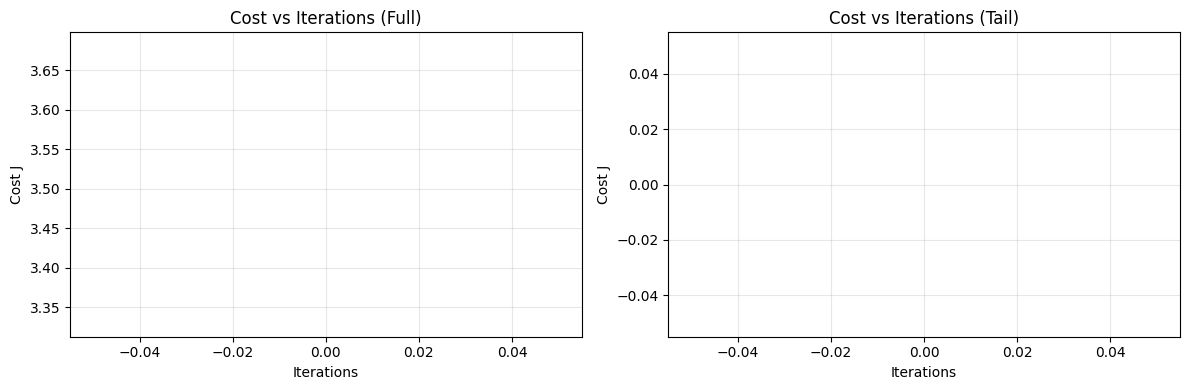

In [ ]:
print(f"Items in J_hist: {len(J_hist)}")
print(f"First 5 costs: {J_hist[:5]}")
# Shows gradient descent working — cost going down!
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# Left — full journey
ax1.plot(J_hist, color="blue")
ax1.set_title("Cost vs Iterations (Full)")
ax1.set_xlabel("Iterations")
ax1.set_ylabel("Cost J")
ax1.grid(True, alpha=0.3)

# Right — zoomed tail
ax2.plot(J_hist[1000:], color="teal")
ax2.set_title("Cost vs Iterations (Tail)")
ax2.set_xlabel("Iterations")
ax2.set_ylabel("Cost J")
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()